<a href="https://colab.research.google.com/github/hafeezgee/HafeezAhmed/blob/main/Vehicle_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

“This project uses YOLOv8 for real-time vehicle detection and counting. It accurately detects cars, buses, trucks, and motorcycles from images. This system can be used in traffic monitoring, smart cities, and road surveillance.”

In [ ]:
!pip install ultralytics
from ultralytics import YOLO
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Load the model
model = YOLO('yolov8x.pt')

Saving v2.jpg to v2.jpg

image 1/1 /content/v2.jpg: 320x640 7 cars, 2 motorcycles, 1 bus, 2289.1ms
Speed: 2.7ms preprocess, 2289.1ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 640)

Detection for: v2.jpg
Total Vehicles: 10


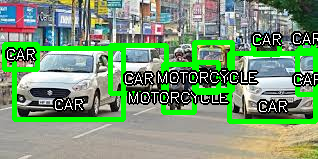

In [ ]:
# 1. Upload Image
uploaded = files.upload()

# Vehicle IDs: 2=car, 3=motorcycle, 5=bus, 7=truck
vehicle_ids = [2, 3, 5, 7]

for filename in uploaded.keys():
    # Run prediction
    results = model.predict(source=filename, conf=0.25, classes=vehicle_ids)

    # Load original image for custom drawing
    img = cv2.imread(filename)

    for result in results:
        boxes = result.boxes
        for box in boxes:
            # Get coordinates
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Get class name
            cls_id = int(box.cls[0])
            label = model.names[cls_id].upper()

            # --- 1. Draw Clean Rectangle ---
            # Using (0, 255, 0) for bright green, thickness of 3
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)

            # --- 2. Calculate Bottom-Middle Position ---
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.5 # Small font
            thickness = 1

            # Get text size to center it
            text_size = cv2.getTextSize(label, font, font_scale, thickness)[0]
            text_x = x1 + (x2 - x1) // 2 - text_size[0] // 2
            text_y = y2 - 10 # 10 pixels up from the bottom line

            # --- 3. Draw Text Background (for readability) ---
            # Optional: Adds a small black shadow so text is visible on any color
            cv2.putText(img, label, (text_x, text_y), font, font_scale, (0,0,0), thickness + 2)
            # Main white text
            cv2.putText(img, label, (text_x, text_y), font, font_scale, (255,255,255), thickness)

        # Count total
        vehicle_count = len(boxes)

        # Display Final Result
        print(f"\nDetection for: {filename}")
        print(f"Total Vehicles: {vehicle_count}")
        cv2_imshow(img)